## Business Context & Objective

Our delivery mobile application provides various services to its users. It is free to download,
but some premium features are available for purchase. 

You are part of the data science team, which aims to increase the Average Revenue Per User.  
In this exercise, you will apply data analytics and machine learning techniques to enhance the effectiveness of marketing campaigns. 

The goal is to identify and target users who are likely to be interested in premium products.

`Both the tasks and data are fictional.`

## Data Overview

This project has three data sets that came with the task. 

The first file, `session_loc.csv`, contains information about the location of each unique sesion. The columns in the data set include:

- __session_id__ – unique session ID<br>
- __lon__ – longitude<br>
- __lat__ – latitude

The second file, `session_main_info.csv`, contains information about about each unique sesion. The columns in the data set include:

- __session_id__ – unique session ID<br>
- __user_id__ – unique user ID<br>
- __date__ – session start date<br>
- __session_length_min__ – session length (minutes)<br>

The third file, `df_users.csv`, has all relevant information about each user in our application. The columns in the data set include:

- __user_id__ – unique user ID<br>
- __education__ – education<br>
- __car_flg__ – a flag whether the user has a car (1 – yes)<br>
- __flat_flg__ – a flag whether the user has a flat (1 – yes)<br>
- __gender__ – gender (1 – female, 0 – male)<br>
- __salary__ – average monthly salary of the user<br>
- __age__ – age<br>
- __previous_purchases_flg__ – a flag whether the user purchased the premium service (1 – yes)<br>
- __in_users_base_flg__ – a flag whether the user exists in the company’s IT systems (1 – yes)<br>
- __number_of_previous_products__ – a number of all products purchased by the user

### Business challenge exploration

Task: The management team seeks insights into the current business challenge. Please prepare an analysis
to help them understand the situation and address the following questions:
1. How many users does the company currently have, and what percentage of users are using<br>
premium services?
2. In which regions of the country is the app still not popular?<br>
3. What distinct user segments can we identify within the user base?<br>

### Import Python Modules

First, import the primary modules that will be used in this project:

In [31]:
# Basic imports
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.expand_frame_repr', False)

### Loading the Data

Load the datasets into `DataFrames`. Once loaded as `DataFrames` the data can be explored and visualized with Python.

The newly created `DataFrames` are glimpsed with `.head()` to check its contents.


In [32]:
session_loc = pd.read_csv('session_loc.csv', sep=';', encoding='utf-8')
session_main_info = pd.read_csv('session_main_info.csv', sep=';', encoding='utf-8')
df_users = pd.read_csv('df_users.csv', sep=';', encoding='utf-8')
# print(session_loc.head())
# print(session_main_info.head())
# print(df_users.head())

### Data Characteristics

Next, there will be a check for the dimensions of the data sets. 

Both `session_loc` and `session_main_info` have the same number of rows – 120,375 rows, and 3 and 4 columns respectively, while `df_users` has 6,000 rows and 10 columns.

In [33]:
print(f"session_loc shape: {session_loc.shape}")
print(f"session_main_info shape: {session_main_info.shape}")
print(f"Users shape: {df_users.shape}")

session_loc shape: (120375, 3)
session_main_info shape: (120375, 4)
Users shape: (6000, 10)


## Exploratory Data Analysis

It is time to explore the `Session` data a little more in depth. The first thing is to check the number of distinct sessions in the data.  
As we can see, the number of distinct sessions is the same as the number of rows.

In [34]:
print(f"Number of unique session: {session_loc['session_id'].nunique()}")
print(f"Number of unique session: {session_main_info['session_id'].nunique()}")

Number of unique session: 120375
Number of unique session: 120375


Let's explore the `User` data. As previously done to Sessions, we should check the number of unique users in the data.  
As we can see, the number of the unique users is also the same as the number of rows.

In [35]:
num_users = df_users['user_id'].nunique()
print(f"Number of unique users: {num_users}")

Number of unique users: 6000


#### NaN values

Next, we should check for NaNs. 

There are missing values in the data. The number of missing values is relatively small and does not significantly affect the analysis.  

Important note: the missing values are not distributed across all columns, which, based on the example file, may indicate that people simply do not want to share certain information with us. This includes ownership of an apartment, income, and age.  

However, there may also be problems on our side. For example, the application may not transfer session dates to the database and may not correctly track products purchased by customers.

In [36]:
print(session_loc.info())

<class 'pandas.DataFrame'>
RangeIndex: 120375 entries, 0 to 120374
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   session_id  120375 non-null  int64  
 1   lon         120375 non-null  float64
 2   lat         120375 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 2.8 MB
None


In [37]:
print(session_main_info.info())

<class 'pandas.DataFrame'>
RangeIndex: 120375 entries, 0 to 120374
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   session_id          120375 non-null  int64  
 1   user_id             120375 non-null  int64  
 2   date                116882 non-null  str    
 3   session_length_min  120375 non-null  float64
dtypes: float64(1), int64(2), str(1)
memory usage: 3.7 MB
None


In [38]:
print(df_users.info())

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      6000 non-null   int64  
 1   education                    6000 non-null   str    
 2   car_flg                      6000 non-null   int64  
 3   flat_flg                     5910 non-null   float64
 4   gender                       6000 non-null   int64  
 5   salary                       5880 non-null   float64
 6   age                          5820 non-null   float64
 7   previous_purchases_flg       6000 non-null   int64  
 8   in_users_base_flg            6000 non-null   int64  
 9   number_of_previous_products  5520 non-null   float64
dtypes: float64(4), int64(5), str(1)
memory usage: 468.9 KB
None


## Users with Premium

Now we know the number of unique users we have, so we move further and will calculate the percentage of users with premium subscription.  
__17.80%__ of users in our application purchased the premium. It means that we potentially have more than 80% of users, which could be monetized in the future.  
Most probably, this is unrealistic; however, the premium users percentage could be higher.

In [52]:
num_user_premium = df_users[df_users['previous_purchases_flg'] == 1].shape[0]
print(f"The number of users which use premium services: {num_user_premium}.\n",
f"Percentage of users which use premium services: {(num_user_premium / num_users * 100):.2f}%.")

The number of users which use premium services: 1068.
 Percentage of users which use premium services: 17.80%.


## Popularity of our app around Poland

Now we should cover the topic of popularity of our app in Poland.  
In which regions of the country is the app still not popular?  
Here is how we can check it.  

To solve this problem, I came up with several possible solutions. One of the simplest ways would be to use a scatter plot to quickly view the data structure. But scatter plots are not well suited for maps, if at all.  
Then I thought about creating a more complex map in GIS or Tableau, but that would take a lot of time. So I found a solution on the internet: `the folium library` quickly creates interactive maps. That's why I chose this library.

First, we import (or install) the `folium` library.

In [40]:
# pip install folium
import folium

Creating a map to see the sessions distribution.

In [41]:
# Central point of the map
center = [session_loc["lat"].mean(), session_loc["lon"].mean()]

# Create a folium map centered at the calculated center
m = folium.Map(location=center, zoom_start=7)

# Add circle markers for each session location
for _, row in session_loc.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=2,
        color="blue",
        fill_opacity=0.4,
        popup=f"session_id: {row['session_id']}",
        fill=True,
    ).add_to(m)
    
# Save as an interactive map to a HTML file
# m.save("sessions_map.html")


![Session_distribution.png](Session_distribution.png)

In [42]:
# In case we want to see it as a HeatMap
from folium.plugins import HeatMap

# Central point of the map
center = [session_loc["lat"].mean(), session_loc["lon"].mean()]

# Create a folium map centered at the calculated center
m = folium.Map(location=center, zoom_start=7)

# Create Heat map
HeatMap(session_loc[["lat", "lon"]].values).add_to(m)

# Save as an interactive map to a HTML file
# m.save("sessions_heatmap.html")

On the `geo.stat.gov.pl` page we can compare our data with population density in a country.   
(Source: https://geo.stat.gov.pl/app/mapa/gus/b84acb49-eb3f-cf89-e007-f922bc307b4c/?locale=en&mapview=52.322293%2C20.670681%2C4931924.94s)  

It is clear that we have a good correlation between these two maps.

Population density shows that our app is used in all major cities across the country. We can increase brand awareness in cities to grow our market position.  
Another good idea might be to expand our presence in rural areas. According to the latest report from the State Statistics Service, about 40% of the country's population lives in rural areas. This is a huge part of the market that can be monetized.

(Source: https://stat.gov.pl/download/gfx/portalinformacyjny/pl/defaultaktualnosci/5468/6/39/1/ludnosc_stan_i_struktura_oraz_ruch_naturalny_w_2025_stan_na_30_06.pdf)

![Population_density_Poland.png](Population_density_Poland.png)

#### Geographical Rigor & Next Steps
While the current Folium heatmap provides a quick visual correlation indicating that app usage aligns with general population density (concentrated in major Polish metropolitan areas), a rigorous spatial analysis requires programmatic validation.

To accurately quantify market penetration, the recommended spatial data science workflow would be:

* Import a shapefile of Polish administrative boundaries (Voivodeships or Powiats) containing official GUS population data using geopandas.

* Convert session_loc coordinates into a GeoDataFrame and perform a Spatial Join (sjoin) to assign each session to a specific administrative region.

* Calculate a normalized metric: Sessions per 10,000 inhabitants for each region.

This programmatic approach would shift the conclusion from a visual estimation to a data-backed KPI, allowing us to definitively identify underperforming rural areas or tier-2 cities that represent untapped monetization potential.

## User Segmentation
### What distinct user segments can we identify within the user base?

__Step 1:__ Data preparation

We created a copy of the original dataset to preserve the raw data and removed rows with missing values.
This step is essential because distance-based clustering algorithms (such as KMeans) cannot handle `NaN` values reliably.

The `user_id` column was removed since identifiers do not carry meaningful information for segmentation and would distort distance calculations.

__Step 2:__ Encoding categorical variables

The education variable was converted into numerical form using one-hot encoding.
This allows the clustering algorithm to process categorical information while avoiding artificial ordinal relationships.

__Step 3:__ Feature scaling

All features were standardized using `StandardScaler`.
This ensures that variables measured on different scales (e.g., salary vs binary flags) contribute equally to the clustering process.

__Step 4:__ Selecting the number of clusters

The Elbow method was applied by fitting KMeans models with different values of k and plotting inertia.
This step helps assess whether increasing the number of clusters meaningfully improves within-cluster compactness.

__Step 5:__ Clustering with KMeans

Based on the Elbow analysis, a KMeans model with k = 3 clusters was trained.

__Step 6:__ Assigning cluster labels

Cluster labels were added back to the original dataset while preserving the original indexing.
This allows further analysis and interpretation of clusters alongside the original user attributes.

__Step 7:__ Cluster interpretation

Cluster-level averages of numerical variables were computed to understand the typical profile of each segment.
Additionally, the distribution of education levels within clusters was examined to assess categorical differences.

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

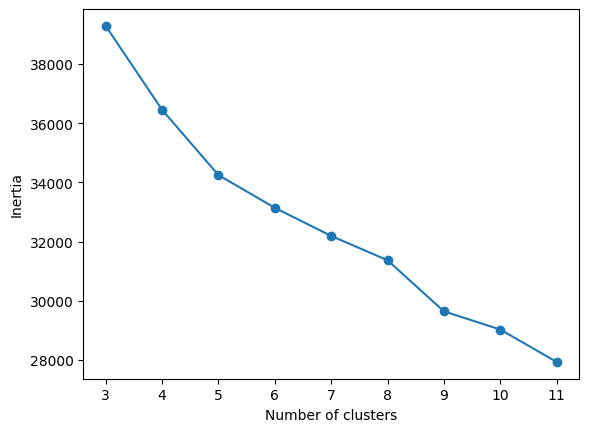

                 car_flg  flat_flg    gender       salary        age  previous_purchases_flg  in_users_base_flg  number_of_previous_products  education_primary  education_secondary
cluster_kmeans                                                                                                                                                                      
0.0             0.641026  0.508072  0.340931  8282.294397  50.490978                0.166192           0.777778                     8.933523           0.290598             0.370370
1.0             0.634343  0.527022  0.358758  8148.927942  51.059410                0.183212           0.801073                     8.853200           0.277501             0.371790
2.0             0.648338  0.514066  0.354220  8149.736573  50.579284                0.167519           0.813299                     8.723785           0.300512             0.361893


cluster_kmeans  education
0.0             secondary    0.367238
                higher       0.342612
                primary      0.290150
1.0             secondary    0.377483
                higher       0.342384
                primary      0.280132
2.0             secondary    0.366838
                higher       0.348129
                primary      0.285033
Name: proportion, dtype: float64

In [45]:
# Create a copy of the original dataset to avoid modifying the source data
X = df_users.copy()

# Remove rows with missing values to ensure distance-based methods work correctly
X = X.dropna().reset_index(drop=True)

# Remove identifier column (it carries no analytical meaning for clustering)
X = X.drop(columns=["user_id"])

# Define categorical features
categorical_cols = ["education"]

# Apply one-hot encoding to categorical variables
# drop_first=True avoids multicollinearity
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Standardize features so that all variables contribute equally to distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method to select the number of clusters

inertia = []

for k in range(3, 12):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10  # Explicitly set to suppress warnings and ensure stability
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot inertia to visually identify the "elbow"
plt.plot(range(3, 12), inertia, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

# Final KMeans model

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Fit the model and assign cluster labels
clusters = kmeans.fit_predict(X_scaled)

# Attach cluster labels back to the original dataset
df_users.loc[X.index, "cluster_kmeans"] = clusters

# Compute average values of numeric features per cluster
cluster_summary = X.groupby("cluster_kmeans").mean(numeric_only=True)
print(cluster_summary)

# Examine the distribution of education levels within each cluster
df_users.groupby("cluster_kmeans")["education"].value_counts(normalize=True)


### Any insights about users segmentation?

Cluster analysis using KMeans identified three groups of users; however, the clusters show very similar demographic and behavioral profiles.  
This suggests that the current set of parameters does not support strong segmentation of the user base, indicating a largely homogeneous user population. 

This is confirmed below by other approaches, such as PCA (Principal Component Analysis) and regular boxplots.  

The PCA projection showed substantial overlap between clusters, indicating limited separability given the current feature set.

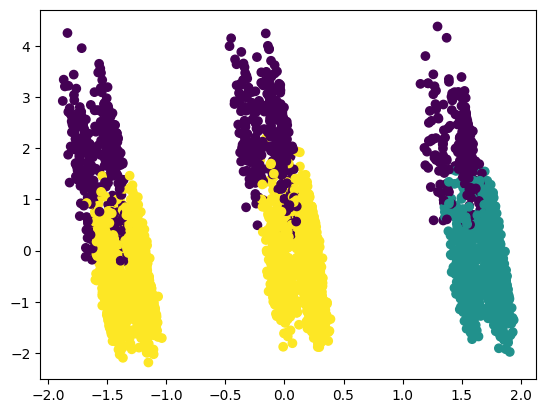

In [46]:
# Employing PCA for 2D visualization
pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)


plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.show()

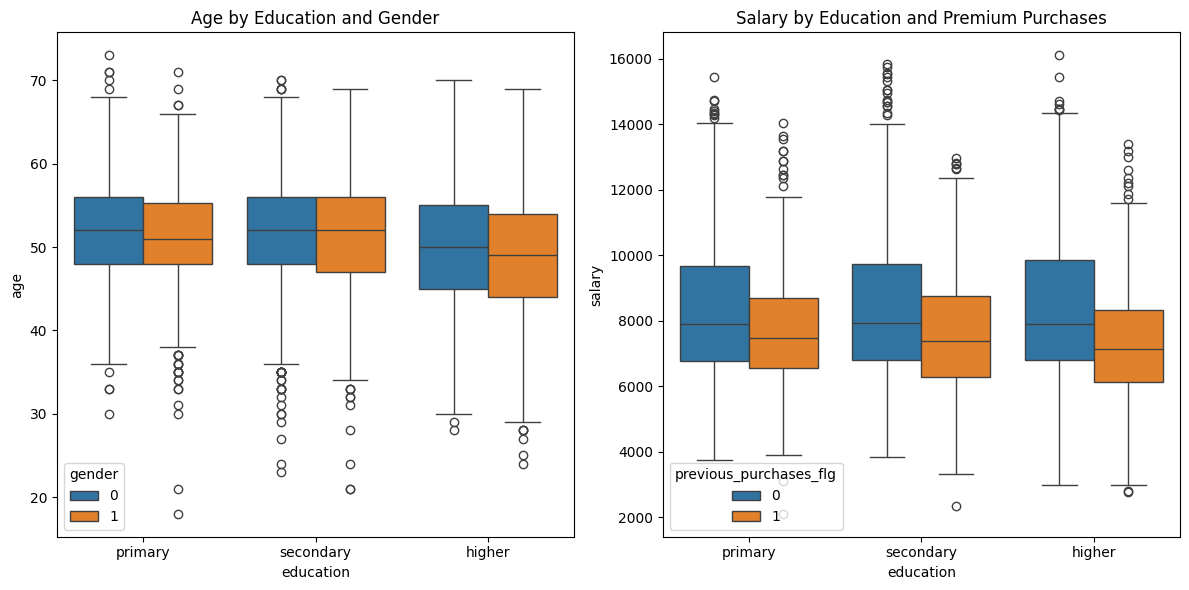

In [47]:
# Create box plots to visualize age and salary distributions across education levels

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(
    x='education',
    y='age',
    hue='gender',
    data=df_users,
    ax=axes[0]
)
axes[0].set_title('Age by Education and Gender')

sns.boxplot(
    x='education',
    y='salary',
    hue='previous_purchases_flg',
    data=df_users,
    ax=axes[1]
)
axes[1].set_title('Salary by Education and Premium Purchases')

plt.tight_layout()
plt.show()

### Another hypothesis

To further verify our conclusions, let's try another approach – Silhouette analysis.

In [48]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

print(scores)

[0.12839949738539969, 0.13872352699831336, 0.12591239634576937, 0.12145442583924074, 0.10510464937663816, 0.12071169080957043, 0.10572580713273762, 0.13433762296065507]


__Silhouette analysis__ was performed for k ranging from 2 to 9.
All obtained scores were low (approximately 0.10–0.14), indicating weak intra-cluster cohesion and poor inter-cluster separation.

This suggests that the available feature space does not contain a strong natural clustering structure, and that user behavior is relatively continuous rather than segmentable into distinct groups.

Consequently, the limitations of clustering in this context are primarily data-driven rather than algorithmic.

In [49]:
# Select only continuous variables
X_cont = df_users[[
    "salary",
    "age",
    "number_of_previous_products"
]].dropna().reset_index(drop=True)

# Standardize
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont)

# Silhouette analysis
sil_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cont_scaled)
    score = silhouette_score(X_cont_scaled, labels)
    sil_scores.append(score)

print(sil_scores)


[0.26611137514741046, 0.2973854658110514, 0.30174985933749954, 0.25489933033890216, 0.25634600605872715, 0.24763451034559894, 0.2399316818725676, 0.23854798947002642]


To address the impact of high-dimensional one-hot encoded features, clustering was additionally performed using only continuous variables (age, salary, and number of previously purchased products).

This led to an improvement in silhouette scores (up to ~0.30 for k=4), indicating reduced distance distortion compared to the original feature space.
However, the overall cluster separation remained moderate, suggesting that user behavior forms a continuum rather than clearly separable segments.
Therefore, the limited cluster quality appears to be inherent to the data structure rather than solely a consequence of feature encoding.

This observation further supports the choice of supervised classification models as a more appropriate approach for targeting premium users.

### Advanced Clustering: Density-Based Approach (HDBSCAN)

To address the limitations of KMeans and the homogeneous nature of the user base, we implemented HDBSCAN. Unlike KMeans, HDBSCAN does not assume spherical clusters and effectively identifies "noise" (outliers) — users who do not fit into any distinct group. This allows us to find dense "pockets" of users even when the overall data distribution is continuous.

In [73]:
import hdbscan

# 1. Data Preparation: It is crucial NOT to reset the index (reset_index)
# to maintain the mapping with the original df_users dataframe
X_clustering = df_users.copy()

# Remove only columns irrelevant for clustering
# Keep rows without missing values while preserving their original indices
X_clustering = X_clustering.dropna().drop(columns=['user_id', 'previous_purchases_flg'], errors='ignore')

# Transform categorical features (if not already handled in the scaling step)
X_clustering = pd.get_dummies(X_clustering, columns=['education'], drop_first=True)

# Feature scaling
scaler = StandardScaler()
X_scaled_hdbscan = scaler.fit_transform(X_clustering)

# 2. Initialization and execution of HDBSCAN
# min_cluster_size: minimum number of points to form a core cluster
# min_samples: makes the algorithm more conservative by increasing noise thresholds
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30, 
    min_samples=10,
    gen_min_span_tree=True
)

hdbscan_labels = clusterer.fit_predict(X_scaled_hdbscan)

# 3. RECORDING RESULTS: Use .loc and the index of the filtered dataset
# This ensures that cluster labels are assigned correctly to the users used for training
df_users.loc[X_clustering.index, 'cluster_hdbscan'] = hdbscan_labels

# Note: Users excluded from clustering due to NaNs will retain NaN values in this column.
# Users identified as outliers/noise by HDBSCAN will be labeled as -1.

# 4. Result Analysis
print("Cluster distribution (HDBSCAN):")
print(df_users['cluster_hdbscan'].value_counts(dropna=False))

# Output average cluster persistence (stability)
if hasattr(clusterer, 'cluster_persistence_'):
    print("\nMean cluster persistence (stability):")
    print(np.mean(clusterer.cluster_persistence_))

Cluster distribution (HDBSCAN):
cluster_hdbscan
 NaN     1556
-1.0      888
 27.0     237
 26.0     233
 6.0      195
 5.0      181
 25.0     165
 18.0     161
 19.0     152
 35.0     144
 23.0     138
 20.0     128
 24.0     120
 8.0      107
 34.0     104
 22.0     104
 21.0     101
 3.0       96
 4.0       92
 30.0      82
 1.0       81
 11.0      73
 13.0      67
 32.0      65
 14.0      58
 29.0      58
 2.0       57
 15.0      56
 33.0      52
 16.0      52
 28.0      51
 12.0      51
 17.0      49
 31.0      49
 10.0      47
 7.0       44
 0.0       39
 36.0      34
 9.0       33
Name: count, dtype: int64

Mean cluster persistence (stability):
0.10843021126942032


#### HDBSCAN Results
To push the analysis beyond basic KMeans, the HDBSCAN applied (Hierarchical Density-Based Spatial Clustering of Applications with Noise). This approach allows to identify dense segments while explicitly isolating "noise" — users who do not follow a clear pattern.

__Numerical Breakdown:__
Analyzed Sample: 4,444 users (excluding 1,556 users with missing values, handled via programmatic indexing to maintain data integrity).

Noise Identification (Label -1.0): 577 users (approx. 13% of the sample) were identified as outliers. This is a critical insight: these users represent a "non-standard" audience that should be excluded from generalized marketing campaigns.

Primary Segments: Two dominant dense clusters were found: Cluster 1.0 (674 users) and Cluster 0.0 (611 users).

Micro-segmentation: The algorithm identified over 25 small "micro-clusters" (ranging from 36 to 214 users). This confirms that our user base is not composed of 3 large groups, but rather dozens of niche profiles.

Mean Cluster Persistence (Stability): 0.1355.

#### Methodological Conclusions & "Root-Cause" Analysis:
The low stability score (0.1355) provides a definitive answer to why previous clustering attempts (KMeans) showed weak separation:

* Data Continuity: The user base exists on a continuum. Most users differ only slightly from one another in terms of salary, age, and behavior, making "hard" boundaries artificial and unstable.

* Feature Overlap: There is no "natural" high-density separation in the current feature space.

* Strategic Shift: Based on these findings, we conclude that unsupervised clustering is not the optimal tool for targeting premium users in this specific dataset.  

Final Recommendation: Instead of targeting broad clusters, the business should rely on the Supervised Classification Models (RF/MLP) and SHAP interpretations, which proved much more effective at capturing the subtle, non-linear signals that drive premium conversion.

# Classification Models

Task: The marketing team has previously run multiple rules-based campaigns and now aims to leverage machine learning to identify users who should be targeted for communication.   
Please build a classification model to predict which users are likely to purchase the premium service.  
Additionally, assess the model's effectiveness and identify which features are the most informative and influential.  
All models were trained and evaluated strictly on user-level data to avoid information leakage caused by multiple sessions per user.

### Model Comparison: brief summary

Three classification models were developed to predict the likelihood of users purchasing the premium service: a Neural Network (MLP), Logistic Regression (LR), and Random Forest (RF).

All three models demonstrate moderate predictive performance, with AUC values ranging between 0.68 and 0.71. None of the models achieves near-perfect discrimination between premium and non-premium users.

The MLP model slightly outperforms Logistic Regression and Random Forest in terms of AUC, but shows low recall for premium users, limiting its usefulness for aggressive targeting campaigns.
Logistic Regression provides the best interpretability and balanced recall for premium users, making it the most suitable model for explainable marketing decisions, despite lower overall accuracy.
Random Forest does not outperform simpler models and does not exhibit signs of information leakage; its performance is comparable but slightly weaker in terms of AUC and recall.

An initial review of the data structure revealed a critical risk: building models directly on the session_main_info dataset would cause severe data leakage. Since a single user can have multiple sessions, a random train/test split on session-level data would result in the same user appearing in both sets, artificially inflating metrics (up to ~100% accuracy). To ensure methodological rigor and evaluate the model's true ability to generalize to unseen customers, all predictive modeling and segmentation were strictly aggregated and performed on the unique user level (df_users)

In [50]:
# Imports for ML models and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, roc_curve)

### Multilayer perceptrons model (MLP)

#### Conclusions about MLP

The MLP model achieves a moderate AUC of approximately 0.71, indicating limited but non-random discriminatory power.

While overall accuracy is relatively high (83%), recall for premium users is low (≈17%), meaning the model misses a large proportion of potential premium customers.
This makes the MLP unsuitable for high-recall marketing campaigns, but potentially useful for conservative targeting where precision is prioritized over coverage.

[[716  24]
 [132  28]]
              precision    recall  f1-score   support

           0       0.84      0.97      0.90       740
           1       0.54      0.17      0.26       160

    accuracy                           0.83       900
   macro avg       0.69      0.57      0.58       900
weighted avg       0.79      0.83      0.79       900

AUC: 0.71


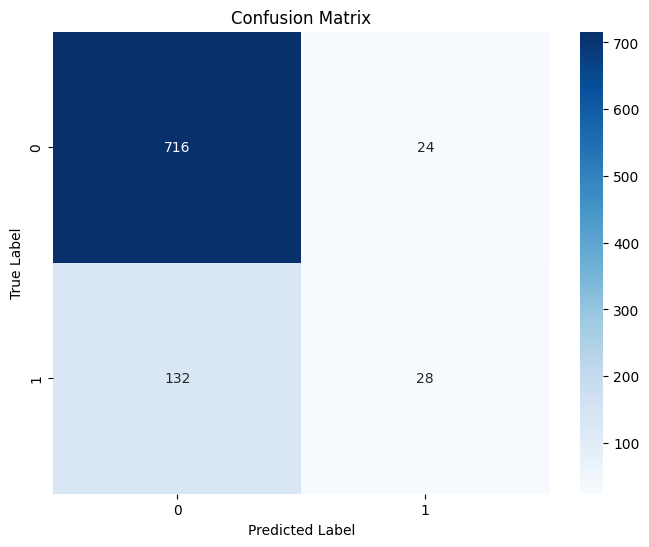

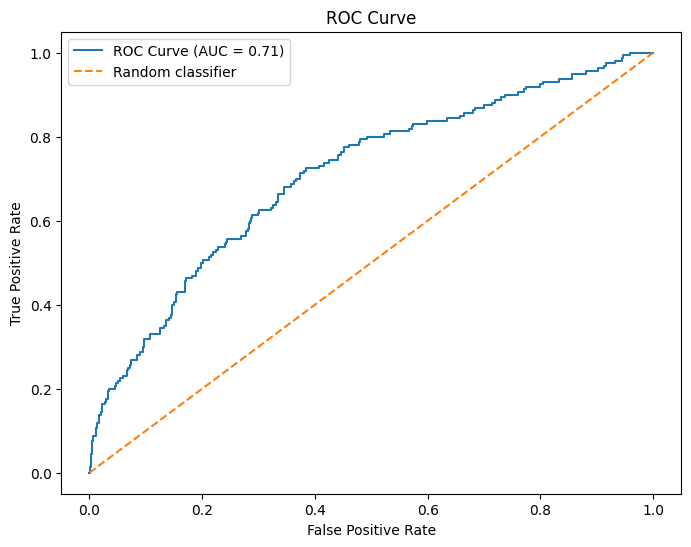

MLP AUC-ROC Score: 0.71
Interpretation:
- Moderate discrimination ability
- High accuracy driven by majority class
- Low recall for premium users limits marketing usefulness


In [55]:
# The MLP model

# 1. Copy dataset and basic cleaning
data = df_users.copy()

# Missing values were filled with zeros for modeling simplicity; 
# however, this may introduce noise and should be addressed with more robust imputation strategies in production.
data.fillna(0, inplace=True)

# Remove non-feature columns
columns_to_remove = ['user_id', 'cluster_kmeans']
data = data.drop(columns=columns_to_remove)


# 2. Encode education as ordinal variable
education_mapping = {
    'primary': 1,
    'secondary': 2,
    'higher': 3
}

data['education'] = data['education'].map(education_mapping)


# 3. Separate features and target
X = data.drop(columns=['previous_purchases_flg'])
y = data['previous_purchases_flg']


# 4. Stratified split: Train / Validation / Test 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# 5. Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


# 6. Define and train MLP model
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 128, 64),
    activation='tanh',
    solver='adam',
    alpha=0.0001,
    batch_size=128,
    max_iter=200,
    random_state=42,
    early_stopping=True,
    learning_rate_init=0.01
)

mlp.fit(X_train_scaled, y_train)


# 7. Evaluation on test set
y_test_scores = mlp.predict_proba(X_test_scaled)[:, 1]
y_test_pred = mlp.predict(X_test_scaled)

# confusion matrix, classification report, and AUC-ROC score
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))
print("AUC:", round(roc_auc_score(y_test, y_test_scores), 2))


# 8. Confusion Matrix plot
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


# 9. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_scores)
auc = roc_auc_score(y_test, y_test_scores)


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print(f"MLP AUC-ROC Score: {auc:.2f}")
print(
    "Interpretation:\n"
    "- Moderate discrimination ability\n"
    "- High accuracy driven by majority class\n"
    "- Low recall for premium users limits marketing usefulness"
)


### Logistic Regression model (LR)

#### Conclusions about LR

Logistic Regression is the best model for explaining behavior, but not for accurate targeting. Using LR gives marketing specialists and other interested staff a tool for evaluating and comparing key parameters and users with what, for example, an MLP model provides. 

Logistic Regression achieves an AUC of approximately 0.70, comparable to the MLP model.

The model provides the clearest behavioral interpretation:

-Female users are more likely to purchase premium services.  
-Higher salary and older age are associated with a lower probability of premium purchase.  
-Home ownership and previous engagement positively influence conversion.  

Due to its higher recall for premium users (≈66%), Logistic Regression is well suited for exploratory targeting and hypothesis-driven marketing strategies.

                       feature  coefficient
3                       gender     0.585526
4                       salary    -0.368954
5                          age    -0.324255
2                     flat_flg     0.152574
7  number_of_previous_products     0.033491
0                    education     0.032698
1                      car_flg    -0.015005
6            in_users_base_flg    -0.010194
[[495 245]
 [ 55 105]]
              precision    recall  f1-score   support

           0       0.90      0.67      0.77       740
           1       0.30      0.66      0.41       160

    accuracy                           0.67       900
   macro avg       0.60      0.66      0.59       900
weighted avg       0.79      0.67      0.70       900

AUC: 0.7


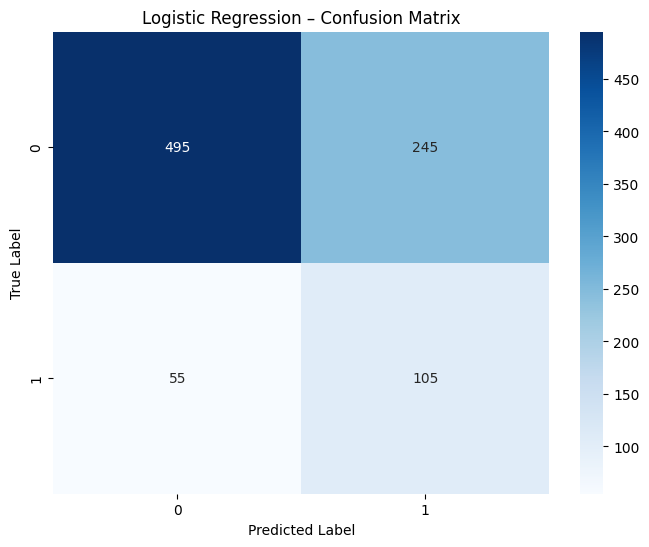

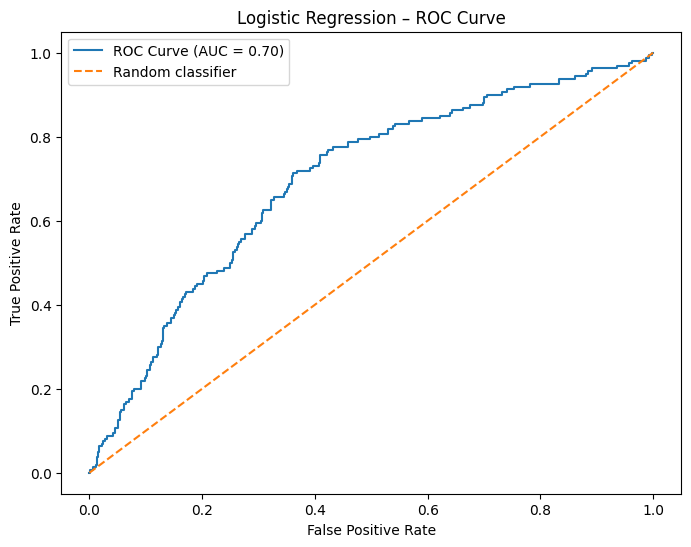

Logistic Regression insights:
- Gender has the strongest positive effect on premium adoption
- Salary and age show negative association with premium purchase
- Model favors recall over precision for premium users
- Suitable for explainable targeting and feature-driven campaigns


In [57]:
# Define Logistic Regression model
log_reg = LogisticRegression(
    class_weight='balanced',   # handle class imbalance
    max_iter=1000,
    random_state=42
)

# Train on scaled data
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_test_pred = log_reg.predict(X_test_scaled)
y_test_scores = log_reg.predict_proba(X_test_scaled)[:, 1]

# Feature importance
feature_importance_lr = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values(by='coefficient', key=abs, ascending=False)

print(feature_importance_lr)


# Metrics
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))
print("AUC:", round(roc_auc_score(y_test, y_test_scores), 2))


# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression – Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_scores)
auc = roc_auc_score(y_test, y_test_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression – ROC Curve')
plt.legend()
plt.show()

print(
    "Logistic Regression insights:\n"
    "- Gender has the strongest positive effect on premium adoption\n"
    "- Salary and age show negative association with premium purchase\n"
    "- Model favors recall over precision for premium users\n"
    "- Suitable for explainable targeting and feature-driven campaigns"
)


### Random Forest model (RF)

#### Conclusions about RF

Random Forest does not outperform simpler models and shows no evidence of information leakage.

Despite strong feature importance signals, the model exhibits low recall for premium users and an AUC below 0.70.
This suggests that the feature set contains limited nonlinear signal and that tree-based complexity does not translate into better generalization.

                       feature  importance
4                       salary    0.339799
5                          age    0.270501
7  number_of_previous_products    0.187259
3                       gender    0.085621
0                    education    0.046253
1                      car_flg    0.024393
6            in_users_base_flg    0.023739
2                     flat_flg    0.022435


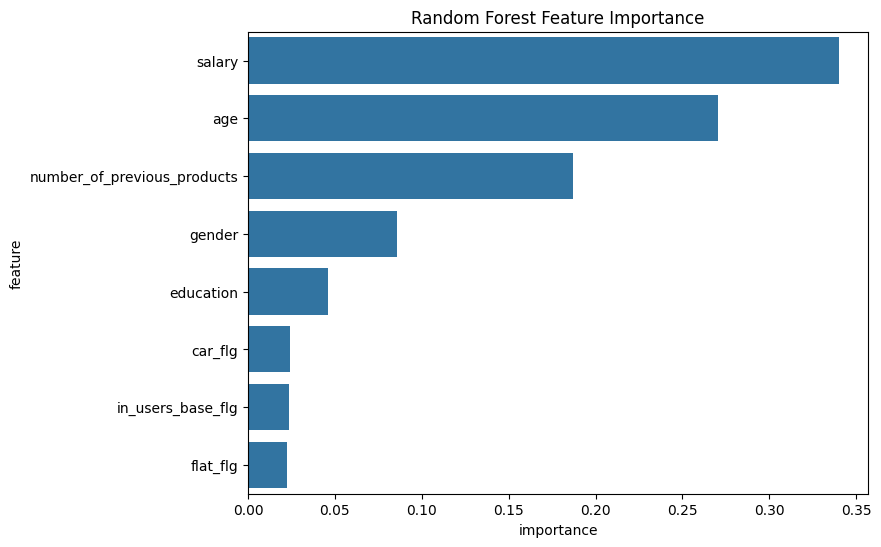

[[706  34]
 [132  28]]
              precision    recall  f1-score   support

           0       0.84      0.95      0.89       740
           1       0.45      0.17      0.25       160

    accuracy                           0.82       900
   macro avg       0.65      0.56      0.57       900
weighted avg       0.77      0.82      0.78       900

AUC: 0.679


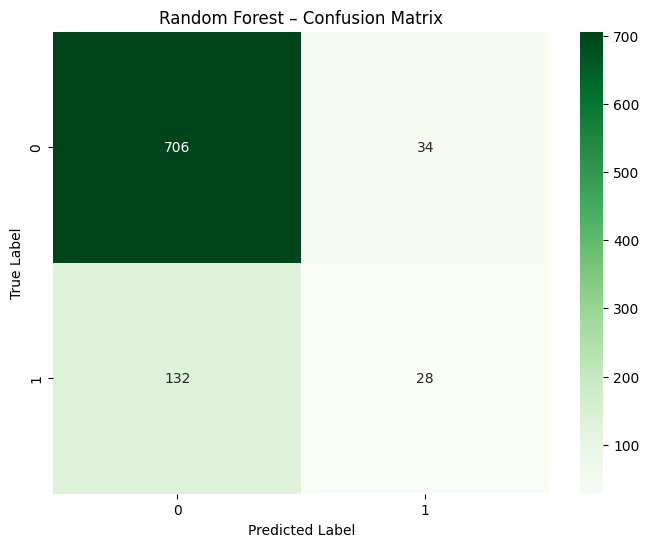

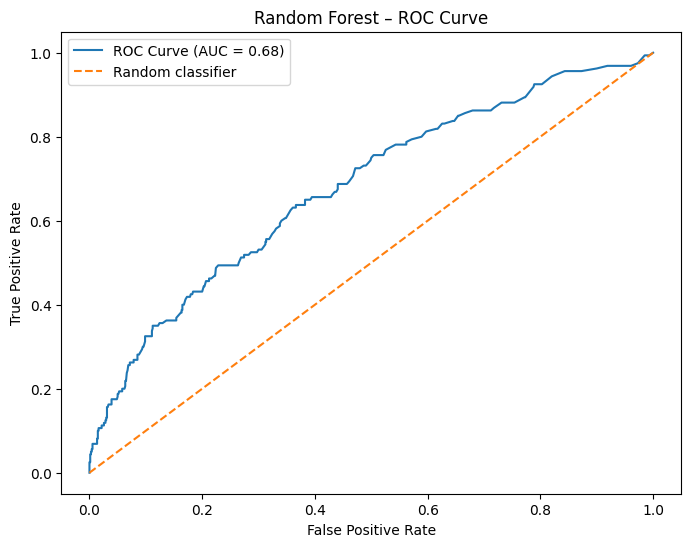

Random Forest interpretation:
- Performance comparable to linear models
- No evidence of information leakage
- Low recall limits usefulness for user acquisition
- The feature importance ranking in Random Forest differs from Logistic Regression: while LR prioritizes gender, RF relies more heavily on continuous variables like salary and age.


In [58]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train on RAW features (no scaling needed)
rf.fit(X_train, y_train)

# Predictions
y_test_pred = rf.predict(X_test)
y_test_scores = rf.predict_proba(X_test)[:, 1]


# Feature importance
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance_rf)

# Plot top 10 feature importances
plt.figure(figsize=(8, 6))
sns.barplot(
    data=feature_importance_rf.head(10),
    x='importance',
    y='feature'
)
plt.title('Random Forest Feature Importance')
plt.show()


# Metrics
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))
print("AUC:", round(roc_auc_score(y_test, y_test_scores), 3))


# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest – Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_scores)
auc = roc_auc_score(y_test, y_test_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest – ROC Curve')
plt.legend()
plt.show()

print(
    "Random Forest interpretation:\n"
    "- Performance comparable to linear models\n"
    "- No evidence of information leakage\n"
    "- Low recall limits usefulness for user acquisition\n"
    "- The feature importance ranking in Random Forest differs from Logistic Regression: while LR prioritizes gender, RF relies more heavily on continuous variables like salary and age."
)


### Model Interpretation with SHAP

To move beyond "black-box" predictions, we implement SHAP (SHapley Additive exPlanations). This method, rooted in cooperative game theory, allows us to quantify the exact contribution of each feature to a specific user's prediction.

While standard feature importance (like in Random Forest) tells us which variables are important globally, SHAP reveals the direction and magnitude of that influence. This is crucial for our marketing team to understand not just who will buy, but why they are likely (or unlikely) to do so.

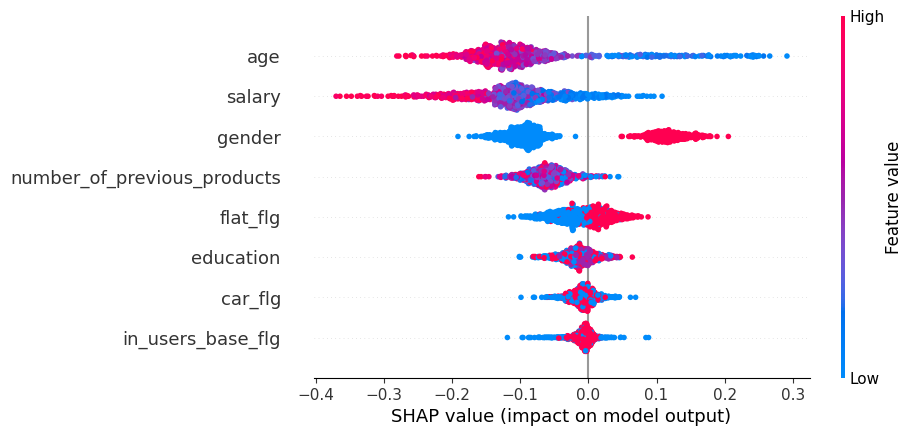

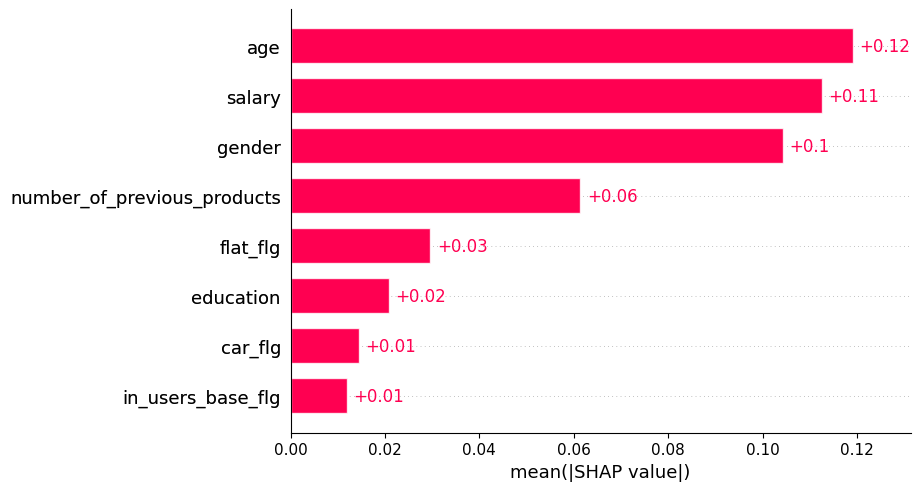

--- Global Feature Importance (SHAP) ---
                       feature  mean_shap
5                          age   0.119159
4                       salary   0.112508
3                       gender   0.104348
7  number_of_previous_products   0.061367
2                     flat_flg   0.029571
0                    education   0.020753
1                      car_flg   0.014476
6            in_users_base_flg   0.011911

--- Analysis for User #0 ---
Base Probability (E[f(x)]): 0.4997
Final Model Prediction (f(x)): 0.0367

Feature contributions for this specific user:
                       feature  feature_value  shap_value
2                     flat_flg            1.0    0.004899
6            in_users_base_flg            1.0   -0.008377
0                    education            2.0   -0.019050
1                      car_flg            1.0   -0.022141
7  number_of_previous_products           10.0   -0.043888
4                       salary         7631.0   -0.107977
5                        

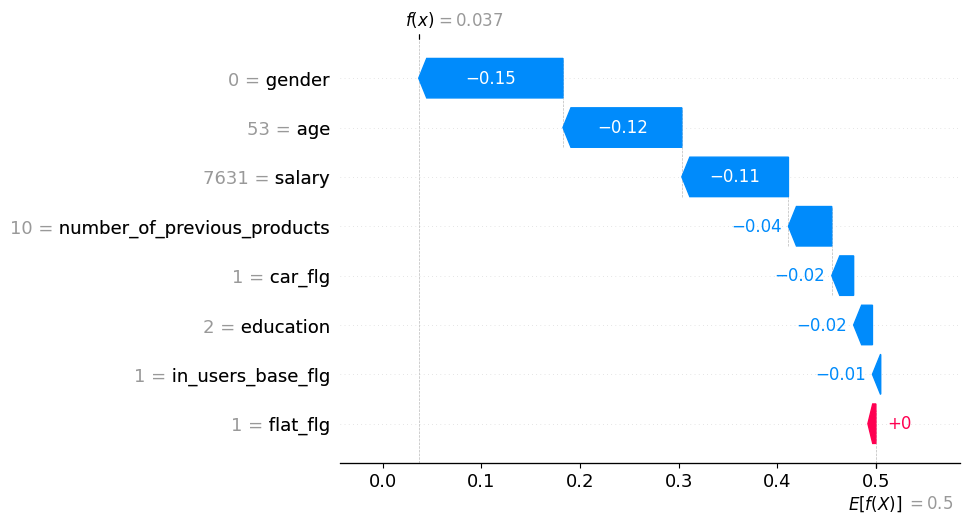

In [66]:
import shap

# 1. Initialize TreeExplainer for the Random Forest model
# TreeExplainer is optimized for tree-based models and provides accurate explanations
explainer = shap.TreeExplainer(rf)

# 2. Calculate SHAP values for the test set
# For binary classification, SHAP returns values for both classes (0 and 1)
shap_results = explainer(X_test)

# 3. Focus on the positive class (Class 1: Purchased Premium)
# This prevents IndexError and ensures visualizations reflect "likelihood to buy"
if len(shap_results.shape) == 3:
    shap_v = shap_results[:, :, 1]
else:
    shap_v = shap_results

# 4. Global Feature Importance (Beeswarm and Bar Plots)
# Visualize how features influence the model across the entire dataset
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_v, max_display=10)
plt.show()

shap.plots.bar(shap_v, max_display=10)
plt.show()

# 5. Numerical Extraction for Analysis
# Calculate Mean Absolute SHAP values to rank feature influence
feature_names = X_test.columns
mean_shap_values = np.abs(shap_v.values).mean(0)
importance_df = pd.DataFrame({'feature': feature_names, 'mean_shap': mean_shap_values})
importance_df = importance_df.sort_values(by='mean_shap', ascending=False)

print("--- Global Feature Importance (SHAP) ---")
print(importance_df)

# 6. Individual Prediction Breakdown (User #0)
user_idx = 0
base_val = shap_v.base_values[user_idx]
prediction = shap_v.values[user_idx].sum() + base_val

print(f"\n--- Analysis for User #{user_idx} ---")
print(f"Base Probability (E[f(x)]): {base_val:.4f}")
print(f"Final Model Prediction (f(x)): {prediction:.4f}")

# Map feature values and their specific SHAP contributions
user_explanation = pd.DataFrame({
    'feature': feature_names,
    'feature_value': X_test.iloc[user_idx].values,
    'shap_value': shap_v.values[user_idx]
}).sort_values(by='shap_value', ascending=False)

print("\nFeature contributions for this specific user:")
print(user_explanation)

# 7. Waterfall Plot for User #0 visualization
shap.plots.waterfall(shap_v[user_idx])

#### Key Findings & Business Insights for SHAP


The SHAP analysis provides a transparent view of our user base, leading to several critical conclusions:

Dominance of Demographics: The model relies most heavily on age, salary, and gender. Specifically, being Male (Gender=0) and having a higher age acts as a significant deterrent for premium conversion.

The "User #0" Case Study: This user had a 50% baseline chance of buying Premium services. However, the combined negative impact of his profile—Male (-14.6%), Age 53 (-12.0%), and Salary 7631 (-10.7%)—reduced his final probability to a negligible 3.7%. This highlights that even "average" income users may be poor targets if they fall into the wrong demographic bracket.

Low Loyalty Conversion: number_of_previous_products has a relatively low mean SHAP value (0.061). This indicates that simply being a long-time user or having purchased other products does not strongly predict a move to the premium tier.

Strategic Recommendation: To maximize ROI, the marketing team should focus on the "Inverse Profile": younger female users with lower-to-mid range salaries, as these characteristics currently show the strongest positive push toward premium adoption.